<a href="https://colab.research.google.com/github/morgane-j/weatherwise-morganej/blob/main/weatherwise7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌦️ WeatherWise – Starter Notebook

Welcome to your **WeatherWise** project notebook! This scaffold is designed to help you build your weather advisor app using Python, visualisations, and AI-enhanced development.

---

📄 **Full Assignment Specification**  
See [`ASSIGNMENT.md`](ASSIGNMENT.md) or check the LMS for full details.

📝 **Quick Refresher**  
A one-page summary is available in [`resources/assignment-summary.md`](resources/assignment-summary.md).

---

🧠 **This Notebook Structure is Optional**  
You’re encouraged to reorganise, rename sections, or remove scaffold cells if you prefer — as long as your final version meets the requirements.

✅ You may delete this note before submission.



## 🧰 Setup and Imports

This section imports commonly used packages and installs any additional tools used in the project.

- You may not need all of these unless you're using specific features (e.g. visualisations, advanced prompting).
- The notebook assumes the following packages are **pre-installed** in the provided environment or installable via pip:
  - `requests`, `matplotlib`, `pyinputplus`
  - `fetch-my-weather` (for accessing weather data easily)
  - `hands-on-ai` (for AI logging, comparisons, or prompting tools)

If you're running this notebook in **Google Colab**, uncomment the following lines to install the required packages.


In [ ]:
# 🧪 Optional packages — uncomment if needed in Colab or JupyterHub
!pip install fetch-my-weather
!pip install hands-on-ai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.9/69.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.2/78.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 459.8/459.8 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 95.3 MB/s eta 0:00:00
  Attempting uninstall: fastcore
    Found existing in

In [ ]:
import os

os.environ['HANDS_ON_AI_SERVER'] = 'http://ollama.serveur.au'
os.environ['HANDS_ON_AI_MODEL'] = 'granite3.2'
os.environ['HANDS_ON_AI_API_KEY'] = input('Enter your API key: ')

## 📦 Setup and Configuration
Import required packages and setup environment.

In [ ]:
!pip install pyinputplus
import requests
import matplotlib.pyplot as plt
import pyinputplus as pyip
# ✅ Import after installing (if needed)
from fetch_my_weather import get_weather
from hands_on_ai.chat import get_response



## 🌤️ Weather Data Functions

In [ ]:
import fetch_my_weather

def get_weather_data(location="Perth", forecast_days=3):

# Fetches the weather in given location and forecast for 3 days
    try:
        weather = fetch_my_weather.get_weather(location=location)
        current = weather.current_condition[0]

        current_conditions = {
            'temperature_C': current.temp_C,
            'condition': current.weatherDesc[0].value,
            'humidity': current.humidity,
            'wind_speed_kmph': current.windspeedKmph
        }
# Formats current weather conditions into a dictionary

        forecast_data = []
        for day in weather.weather[:forecast_days]:
            forecast_data.append({
                'date': day.date,  # Date of forecast
                'min_temp_C': day.mintempC,  # Min temperature for that day
                'max_temp_C': day.maxtempC  # Max temperature for that day
            })

# Prepare forecast data for the specified number of days

        return {
            'location': location,
            'current': current_conditions,
            'forecast': forecast_data
        }

# Return a dictionary with location, current conditions, and forecast


    except Exception as e:  # Handle any errors (e.g., network issues)
        return {"error": str(e)}  # Return error message


# Start of main program

print("Welcome to the Weather App!")
location = input("Enter a location: ")
weather_data = get_weather_data(location)

if "error" in weather_data:
    print("Error:", weather_data["error"])
# Check for errors in fetching data
else:
    print(f"\nCurrent weather in {weather_data['location']}:")
    print(f"Temperature: {weather_data['current']['temperature_C']}°C")
    print(f"Condition: {weather_data['current']['condition']}")
    print(f"Humidity: {weather_data['current']['humidity']}%")
    print(f"Wind Speed: {weather_data['current']['wind_speed_kmph']} km/h")

# Print weather details

    print("\n3-Day Forecast:")
    for day in weather_data['forecast']:
        print(f"{day['date']}: {day['min_temp_C']}°C - {day['max_temp_C']}°C")

# Print 3-day forecast

Welcome to the Weather App!


KeyboardInterrupt: Interrupted by user

## 📊 Visualisation Functions

Starting temperature visualization...
Dates: ['2025-05-21', '2025-05-22', '2025-05-23', '2025-05-24', '2025-05-25']
Min Temps: [10, 11, 13, 12, 14]
Max Temps: [18, 20, 21, 19, 22]
Displaying the temperature plot...


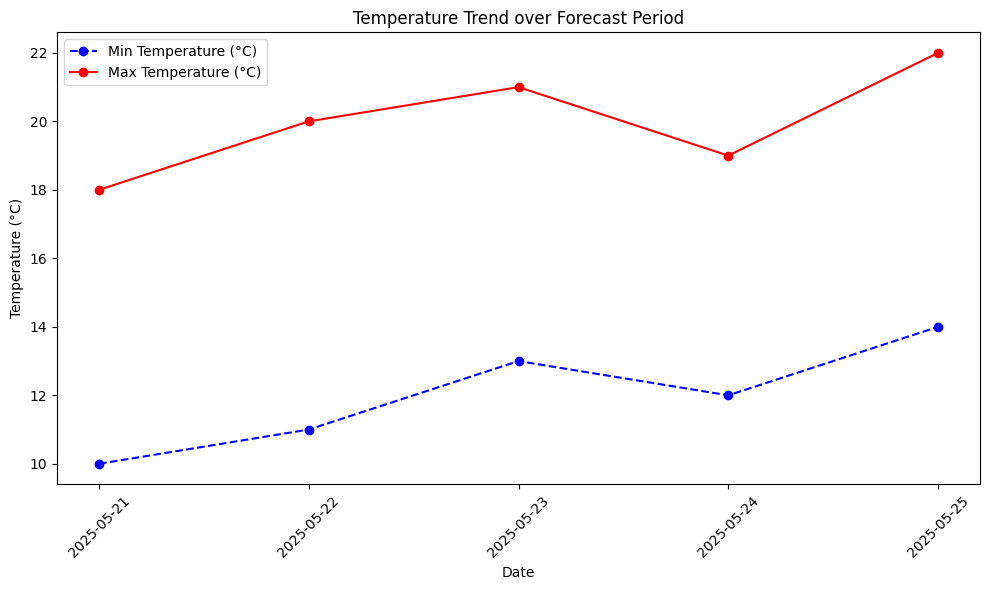

Time taken to display the plot: 0.21 seconds
Starting precipitation visualization...
Dates: ['2025-05-21', '2025-05-22', '2025-05-23', '2025-05-24', '2025-05-25']
Precip Chances: [20, 40, 50, 30, 10]
Displaying the precipitation plot...


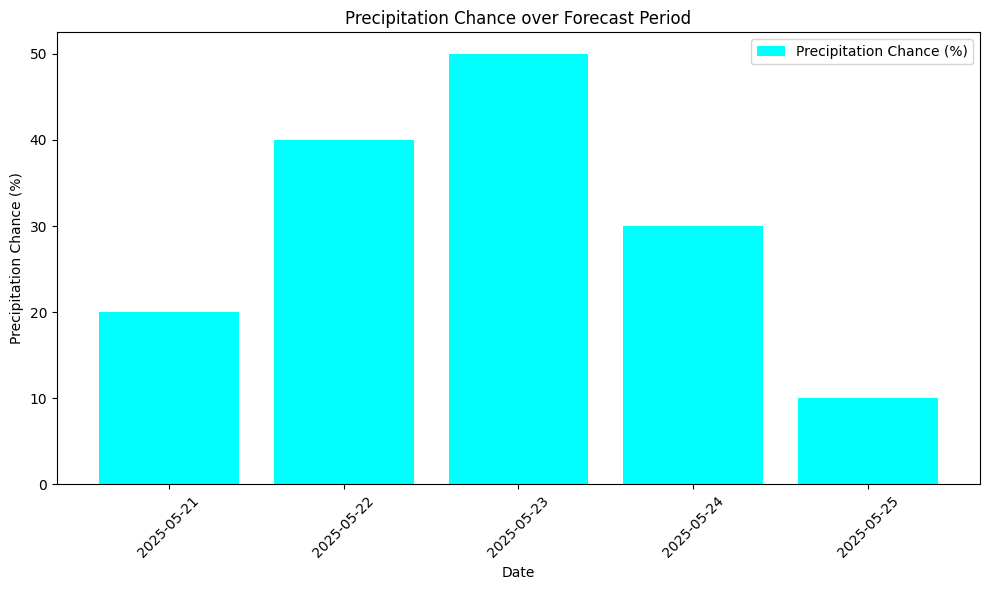

Time taken to display the plot: 0.13 seconds


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import time

def create_temperature_visualisation(weather_data, output_type='display'):
    """
    Create visualization of temperature data.

    Args:
        weather_data (dict): The processed weather data
        output_type (str): Either 'display' to show in notebook or 'figure' to return the figure

    Returns:
        If output_type is 'figure', returns the matplotlib figure object
        Otherwise, displays the visualization in the notebook
    """
    print("Starting temperature visualization...")  # Debugging step

    # Ensure weather data is not empty and contains forecast
    forecast_data = weather_data.get('forecast', [])
    if not forecast_data:
        print("Error: No forecast data available!")
        return

    # Extract the dates and temperature data
    dates = [day['date'] for day in forecast_data]
    min_temps = [day['min_temp_C'] for day in forecast_data]
    max_temps = [day['max_temp_C'] for day in forecast_data]

    # Debugging output: print out the data to confirm
    print(f"Dates: {dates}")
    print(f"Min Temps: {min_temps}")
    print(f"Max Temps: {max_temps}")

    # Set up the plot
    plt.figure(figsize=(10, 6))
    plt.plot(dates, min_temps, marker='o', label='Min Temperature (°C)', color='blue', linestyle='--')
    plt.plot(dates, max_temps, marker='o', label='Max Temperature (°C)', color='red', linestyle='-')
    plt.xlabel('Date')
    plt.ylabel('Temperature (°C)')
    plt.title('Temperature Trend over Forecast Period')
    plt.xticks(rotation=45)
    plt.legend()

    # Show the plot if the output type is 'display'
    if output_type == 'display':
        print("Displaying the temperature plot...")  # Debugging step
        plt.tight_layout()

        start_time = time.time()  # Start tracking the time
        plt.show()  # Display the plot

        # Check how long it takes to show the plot
        elapsed_time = time.time() - start_time
        print(f"Time taken to display the plot: {elapsed_time:.2f} seconds")

    # Return the figure object if output type is 'figure'
    elif output_type == 'figure':
        return plt


def create_precipitation_visualisation(weather_data, output_type='display'):
    """
    Create visualization of precipitation chances.

    Args:
        weather_data (dict): The processed weather data
        output_type (str): Either 'display' to show in notebook or 'figure' to return the figure

    Returns:
        If output_type is 'figure', returns the matplotlib figure object
        Otherwise, displays the visualization in the notebook
    """
    print("Starting precipitation visualization...")  # Debugging step

    # Ensure weather data is not empty and contains forecast
    forecast_data = weather_data.get('forecast', [])
    if not forecast_data:
        print("Error: No forecast data available!")
        return

    # Extract the dates and precipitation chances
    dates = [day['date'] for day in forecast_data]
    precip_chances = [day.get('precipChance', 0) for day in forecast_data]

    # Debugging output: print out the data to confirm
    print(f"Dates: {dates}")
    print(f"Precip Chances: {precip_chances}")

    # Set up the plot
    plt.figure(figsize=(10, 6))
    plt.bar(dates, precip_chances, color='cyan', label='Precipitation Chance (%)')
    plt.xlabel('Date')
    plt.ylabel('Precipitation Chance (%)')
    plt.title('Precipitation Chance over Forecast Period')
    plt.xticks(rotation=45)
    plt.legend()

    # Show the plot if the output type is 'display'
    if output_type == 'display':
        print("Displaying the precipitation plot...")  # Debugging step
        plt.tight_layout()

        start_time = time.time()  # Start tracking the time
        plt.show()  # Display the plot

        # Check how long it takes to show the plot
        elapsed_time = time.time() - start_time
        print(f"Time taken to display the plot: {elapsed_time:.2f} seconds")

    # Return the figure object if output type is 'figure'
    elif output_type == 'figure':
        return plt


# Example usage
weather_data = {
    'location': 'London',
    'current': {
        'temperature_C': 15,
        'condition': 'Clear',
        'humidity': 80,
        'wind_speed_kmph': 10
    },
    'forecast': [
        {'date': '2025-05-21', 'min_temp_C': 10, 'max_temp_C': 18, 'precipChance': 20},
        {'date': '2025-05-22', 'min_temp_C': 11, 'max_temp_C': 20, 'precipChance': 40},
        {'date': '2025-05-23', 'min_temp_C': 13, 'max_temp_C': 21, 'precipChance': 50},
        {'date': '2025-05-24', 'min_temp_C': 12, 'max_temp_C': 19, 'precipChance': 30},
        {'date': '2025-05-25', 'min_temp_C': 14, 'max_temp_C': 22, 'precipChance': 10}
    ]
}

# Generate the visualizations
create_temperature_visualisation(weather_data)
create_precipitation_visualisation(weather_data)


## 🤖 Natural Language Processing

In [ ]:
import re
from datetime import datetime, timedelta

def parse_weather_question(question):
    """
    Parse a natural language weather question into structured data.

    Args:
        question (str): User's weather-related question

    Returns:
        dict: Extracted information including location, time period, and weather attribute
    """
    question = question.lower()
    today = datetime.now().date()

    # Weather attribute keywords
    attributes = {
        'temperature': ['temperature', 'temp', 'hot', 'cold'],
        'rain': ['rain', 'raining', 'precipitation', 'wet'],
        'humidity': ['humidity', 'humid'],
        'wind': ['wind', 'windy']
    }

    # Default attribute
    attribute = 'general'
    for key, keywords in attributes.items():
        if any(word in question for word in keywords):
            attribute = key
            break

    # Time detection
    if "today" in question:
        time_period = today.isoformat()
    elif "tomorrow" in question:
        time_period = (today + timedelta(days=1)).isoformat()
    elif "weekend" in question:
        # Get Saturday and Sunday of the current week
        saturday = today + timedelta((5 - today.weekday()) % 7)
        sunday = saturday + timedelta(days=1)
        time_period = f"{saturday.isoformat()} to {sunday.isoformat()}"
    else:
        # Try to detect a weekday like "Monday"
        weekdays = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
        time_period = 'unspecified'
        for i, day in enumerate(weekdays):
            if day in question:
                days_ahead = (i - today.weekday()) % 7
                target_date = today + timedelta(days=days_ahead)
                time_period = target_date.isoformat()
                break

    # Extract location (very simple rule: look for "in [location]")
    location_match = re.search(r' in ([a-z]+)', question)
    location = location_match.group(1).strip().title() if location_match else None

    return {
        'location': location,
        'time_period': time_period,
        'attribute': attribute
    }

# Call the function with user input
question = input("Ask a weather question: ")
parsed = parse_weather_question(question)
print("Parsed info:", parsed)


KeyboardInterrupt: Interrupted by user

## 🧭 User Interface

In [ ]:
question = input("Ask a weather question: ")
parsed = parse_weather_question(question)
if parsed and parsed['location']:
    weather_data = get_weather_data(parsed['location'])
    reply = generate_weather_response(parsed, weather_data)
    print(reply)
else:
    print("Sorry, I couldn't understand the location in your question.")

## 🧩 Main Application Logic

In [ ]:
def generate_weather_response(parsed_question, weather_data):
    """
    Generate a natural language response to a weather question.

    Args:
        parsed_question (dict): Parsed question data
        weather_data (dict): Weather data

    Returns:
        str: Natural language response
    """
    # Handle errors
    if 'error' in weather_data:
        return f"Sorry, I couldn't retrieve weather data. {weather_data['error']}"

    location = parsed_question.get('location', 'your location')
    time_period = parsed_question.get('time_period', 'unspecified')
    attribute = parsed_question.get('attribute', 'general')

    today = datetime.now().date().isoformat()

    # === CURRENT CONDITIONS ===
    if time_period == today:
        current = weather_data['current']
        if attribute == 'temperature':
            return f"The current temperature in {location} is {current['temperature_C']}°C."
        elif attribute == 'rain':
            return f"It is currently {current['condition'].lower()} in {location}."
        elif attribute == 'humidity':
            return f"The current humidity in {location} is {current['humidity']}%."
        elif attribute == 'wind':
            return f"The current wind speed in {location} is {current['wind_speed_kmph']} km/h."
        else:
            return (f"Right now in {location}, it's {current['condition'].lower()} with a temperature of "
                    f"{current['temperature_C']}°C, humidity at {current['humidity']}%, and wind speed of "
                    f"{current['wind_speed_kmph']} km/h.")

    # === FORECASTED CONDITIONS ===
    if attribute != "temperature":
      return f"I couldn't forecast {attribute}"

    forecast_days = [
        day for day in weather_data['forecast']
        if time_period in day['date'] or time_period == 'unspecified'
    ]

    if not forecast_days:
        return f"I couldn’t find forecast data for {time_period} in {location}."

    # Only provide temperature forecast for future dates
    response_lines = [f"Temperature forecast for {location}:"]
    for day in forecast_days:
        response_lines.append(f"{day['date']}: {day['min_temp_C']}°C to {day['max_temp_C']}°C")

    return "\n".join(response_lines)

while True:
  question = input("Ask a weather question: ")
  parsed = parse_weather_question(question)
  if parsed and parsed['location']:
      weather_data = get_weather_data(parsed['location'])
      reply = generate_weather_response(parsed, weather_data)
      print(reply)
  else:
      print("Sorry, I couldn't understand the location in your question.")

Ask a weather question: is it raining in perth today
It is currently partly cloudy in Perth.
Ask a weather question: what is the weather in perth today
Right now in Perth, it's partly cloudy with a temperature of 22°C, humidity at 55%, and wind speed of 15 km/h.


## 🧪 Testing and Examples

In [ ]:
import doctest
from datetime import datetime

def generate_weather_response(parsed_question, weather_data):
    """
    Generate a natural language response to a weather question.

    Args:
        parsed_question (dict): Parsed question data
        weather_data (dict): Weather data

    Returns:
        str: Natural language response

    >>> from datetime import datetime
    >>> today = datetime.now().date().isoformat()
    >>> parsed = {'location': 'New York', 'time_period': today, 'attribute': 'temperature'}
    >>> weather = {'current': {'temperature_C': '22', 'condition': 'Sunny', 'humidity': '50', 'wind_speed_kmph': '10'}}
    >>> generate_weather_response(parsed, weather)
    'The current temperature in New York is 22°C.'

    >>> parsed = {'location': 'New York', 'time_period': today, 'attribute': 'rain'}
    >>> generate_weather_response(parsed, weather)
    'It is currently sunny in New York.'

    >>> parsed = {'location': 'New York', 'time_period': '2025-05-22', 'attribute': 'temperature'}
    >>> weather = {
    ...     'forecast': [
    ...         {'date': '2025-05-22', 'min_temp_C': '15', 'max_temp_C': '25'},
    ...         {'date': '2025-05-23', 'min_temp_C': '16', 'max_temp_C': '26'}
    ...     ]
    ... }
    >>> generate_weather_response(parsed, weather)
    'Temperature forecast for New York:\\n2025-05-22: 15°C to 25°C'

    >>> parsed = {'location': 'New York', 'time_period': '2025-05-22', 'attribute': 'humidity'}
    >>> generate_weather_response(parsed, weather)
    "I couldn't forecast humidity"

    >>> parsed = {'location': 'New York', 'time_period': '2025-06-01', 'attribute': 'temperature'}
    >>> weather = {'forecast': []}
    >>> generate_weather_response(parsed, weather)
    'I couldn’t find forecast data for 2025-06-01 in New York.'

    >>> parsed = {'location': 'New York', 'time_period': today, 'attribute': 'temperature'}
    >>> weather = {'error': 'API limit exceeded'}
    >>> generate_weather_response(parsed, weather)
    "Sorry, I couldn't retrieve weather data. API limit exceeded"

    >>> # Perth example mimicking user input "What's the weather in Perth?"
    >>> parsed = {'location': 'Perth', 'time_period': today, 'attribute': 'general'}
    >>> weather = {
    ...     'current': {
    ...         'temperature_C': '28',
    ...         'condition': 'Partly Cloudy',
    ...         'humidity': '60',
    ...         'wind_speed_kmph': '20'
    ...     }
    ... }
    >>> sorted(parsed.keys())
    ['attribute', 'location', 'time_period']
    >>> sorted(weather['current'].keys())
    ['condition', 'humidity', 'temperature_C', 'wind_speed_kmph']
    >>> generate_weather_response(parsed, weather)
    "Right now in Perth, it's partly cloudy with a temperature of 28°C, humidity at 60%, and wind speed of 20 km/h."
    """



## 🗂️ AI Prompting Log (Optional)
Add markdown cells here summarising prompts used or link to AI conversations in the `ai-conversations/` folder.